In [1]:
from PIL import Image, ImageOps, ImageFont
import matplotlib.pyplot as plt
from modules.img_processing import DITHER_MODES
from modules.palette_generator import get_asciis, make_1d_bin_palette, make_2d_bin_palette
from modules.print_gallery import print_gallery
from modules.img2chars_mono_1d import img2char_arr_1d
from modules.img2chars_mono_2d import img2char_arr_2d

In [2]:
ASCII_SET = get_asciis()
FONT = ImageFont.truetype("../fonts/CascadiaMono.ttf", 11)
IMG_PATH = "../imgs/irad_grad.bmp"
IMG_SIZE = (32, 32)

In [3]:
two_char_symbols_set = []
for a in ASCII_SET:
    for b in ASCII_SET:
        two_char_symbols_set.append(a + b)

In [4]:
img = Image.open(IMG_PATH).convert("L")
img.thumbnail(IMG_SIZE)

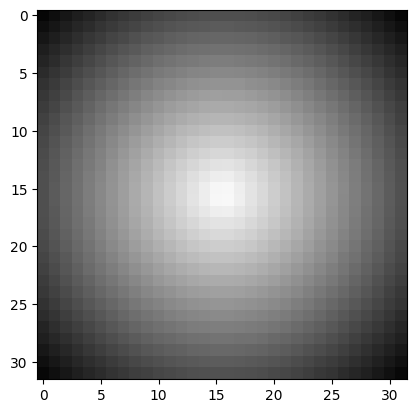

In [5]:
plt.imshow(img, cmap='gray', vmin=0, vmax=255, interpolation='none')

In [6]:
bins = 12
palette, palette_brs = make_1d_bin_palette(
    symbols=ASCII_SET,
    font=FONT,
    bins=bins,
    normalize=True)

doubled_palette, doubled_palette_brs = make_1d_bin_palette(
    symbols=two_char_symbols_set,
    font=FONT,
    bins=bins,
    normalize=True)

results = []
results.append(img2char_arr_1d(
    img=img,
    bin_palette=palette,
    bin_vals=palette_brs))

results.append(img2char_arr_1d(
    img=ImageOps.scale(img, 0.5),
    bin_palette=doubled_palette,
    bin_vals=doubled_palette_brs,
    scale_vertically=False))

print_gallery(results)

-------------------------------------------------------------------------
 | ..':`_--~!^!";//<=~;^;~"-_-:`, . | ...:\ --.C<;I 3,e.a  r/';:= ; .  | 
 | ':'_-!"~~<>>>+>*|/+/<>++!^!_--'' |  ~!,.!`?L;Z_|_z<`KI',e'Yl.\ ;_ ` | 
 | :-_"""/<<?\?\|rLzr?||**+/=~"^-_: | !'_~>,-J\Lj"\?>Itl BV^|<8 <-!-:- | 
 | _-;;</<\*xzLv3[Cn[fLT1r*\*=<!"__ |  +^;p.`A"yO_8;kfH/\fJxK'R.X:c:-` | 
 | -"~>=?|YL)FFaXShhhXI]F1)T\?/+^~" | Y .k"i!C]<17+m#FEfZjzF<7_kl*u'.) | 
 | ~~>+|*viyZkXXw9HPK4khSaa)l\|=<^^ | V :i`%{/fnR[}w2@eBuRpCZTYzh_"?r  | 
 | ~+<?|ira2SkGGw80#gPm9SSoCic?*==~ | >''n9'ox/EgYDPWP&QQb&|jQfuw,[__" | 
 | ^=<**c)fIX%E08$@B$0&qOSXflc?\+<! | ?"K,q^\djK84OMBWMQ@qm0oA9+lo:p,x | 
 | ^/+**)roXkb58&BN@QR06Uhh3Cv|*<>" | /~+L;5zU%IKORgNWWWN&hgqFQ;I<E:f- | 
 | ^=+**c1aokkwdd08R&dO%ShZZYc?\</; | Y`"|\c!b0>K]KPWwm@Wi54{6(3|].a.) | 
 | ;~++\\xieFShXdA%OU6kShVycT**/+!" | x.h.7!:Wkl#r#{84W{VSu8g"z=L/<>|' | 
 | -!~>/?*1clF77kSXXhXZut)L)??><=~; | :(/~llb:xTU{omVbTWZGb<rT!gT+.bV  | 
 | _-^~>=?|*)rlluZ}Zy{T(vY|\?//;~-- | 

In [7]:
bins = 12
palette, palette_brs = make_1d_bin_palette(
    symbols=ASCII_SET,
    font=FONT,
    bins=bins,
    normalize=True)

results = []
results.append(img2char_arr_1d(
    img=img,
    bin_palette=palette,
    bin_vals=palette_brs,
    dither=DITHER_MODES.NONE))

results.append(img2char_arr_1d(
    img=img,
    bin_palette=palette,
    bin_vals=palette_brs,
    dither=DITHER_MODES.BAYER))

results.append(img2char_arr_1d(
    img=img,
    bin_palette=palette,
    bin_vals=palette_brs,
    dither=DITHER_MODES.JJN))

print_gallery(results, 3)

------------------------------------------------------------------------------------------------------------
 | ..'',-_-;;~!~^===>~~!;!~___,',.  | .:.-,-_^-~^+!<!>"/;=~^~"--`-,,.: |  .`,:_-_~"~~!<!/">!!!^~~__-'`` . | 
 | '':--^!~;><>/>=|\//=>+>+;^;---`` | `'_-_-^""<<</+*?|<|<<<<~!;;--:,` | :,'__";"=/+=/==\*>\=>/+~^;;--_,: | 
 | :--;~^/+<\\|\|cii)*\\\\<//!"~_-` | '-_^^=!>/|\|?r|L|Y|L\\/*<=!;_!,_ | '__!;!=+=/??*cY?z\1?**?\/>;"~_-` | 
 | _-^!/=<?*1ivrjaaV7}LLr)***=<!^__ | _-!">+\*|\xvF)ajnjaYxv(*|+<=>^!_ | __^!</+|||vzzCs37tLFl(1|\?>>;"_- | 
 | _"!=>**Lvx7n{XXhShkssfxlz|*/>!!; | _^">+\\z1V(kskIXeSeS]7Yl*c\*;=^" | !^!+<|\TYlaIFkkXSkh7[e1i1**+//"" | 
 | "~=<\\r1{akXk%EbwbAhkXF3Lr*|/=;" | "!++?\zi{IhhkXKGP5dXkJt2Y)v?=/=; | ^!+/\?LveeXhkmEKKbkXSSJIrr\?+="^ | 
 | !</?|LiotXXwq50&8#HPHShyy)L\*/+; | ^//\*vLFZhh9b#wR0&9dh4{hxa\l+?~= | ^>>*\zvt2XkG%H#&&gE4EhSSFrr*?<+" | 
 | ^><||iTIohmK8D$QMW8g6PSXIvv\\/>^ | ;<=\i(xehhO9&#WWWR05dXkV{r)\|<+" | "==\|c{ahSAmRDNNN$0ROEkh}FTz|/<~ | 
 | ^=/*|LrJXkbG&gMB

In [8]:
bins = 12
palette, palette_brs = make_1d_bin_palette(
    symbols=ASCII_SET,
    font=FONT,
    bins=bins,
    normalize=True)

results = []
results.append(img2char_arr_1d(
    img=img,
    bin_palette=palette,
    bin_vals=palette_brs))

bins = (9, 9)
palette, palette_brs = make_2d_bin_palette(
    symbols=ASCII_SET,
    font=FONT,
    bins=bins,
    normalize=True)

results.append(img2char_arr_2d(img, palette))

print_gallery(results)

-------------------------------------------------------------------------
 | ..',`_-_~~!~";/>+<~^~^^^--_`:'.  |   .:::;;!!!!!!!!!!!!!!!!~~:::.   | 
 | `:`--;!^;=</+=/*\+>>/+/<^~;---': | .:::~!!!!|l*\*|11l*>/cc!!!!;:::. | 
 | `--^"!=/>|?|\|L1Li*???*>==~"~__: | ::~!!!\/*i1r[CI{II[[Iii|</!!!~:: | 
 | -_"!=<<?|1ivT{sIs]3LLlT**?+=;;_- | :!!!*l>i{{r22UXXXUS22r]]z\cl!!!: | 
 | _~^/>?|rYx[yJkhShXha2]zxz?\/+!;! | !!!\c1C{2SSS6dKD8KHHS4U2C{zl\!!! | 
 | ~!>>|*1vtZhShA5w4P5XXhC]1z\*=>~; | !!>*iCI2SUA0#8WQQW#88E442rIzc<!! | 
 | ~//?\Lv}nXk6mw0gDg56GkXF7zl?|</^ | !///r}2UU#D0W@@@@@@@00#hX2]r\l|! | 
 | !=>|?lce}XPUg#B@@$DR5dkkVv)\\+/" | !*<>IIhhd08@@@@@@@@@@D#bUUC{[\l! | 
 | ^+<\?(1fXSEO08MM$BgDGwXXV}(||//" | !l<(][X4O#0@@@@@@@@@@000UUI]}*/! | 
 | ^/+?\Ll}}XhU9qgDD&5E6hSj3x(*?+<! | !/*cIrFUX8D0@@@@@@@@$0DXX4{}l\l! | 
 | !^//||)1jjkhkOAH5q5ShhjZLv?\=<~~ | !!|/({{ZhUOD00RRNBB8#PhU4{])l|!! | 
 | -^"+/?*rxYy[7hhSXhhZjJ(v1|?==/~^ | !!=\\(I{ZUSh5P##D0O944SVII(*/=!! | 
 | -_;!+>?|*LvlLnu}{JCvLzL\*|>/^;-- | 

In [9]:
bins = (9, 9)
palette, palette_brs = make_2d_bin_palette(
    symbols=ASCII_SET,
    font=FONT,
    bins=bins,
    normalize=True)

results = []
results.append(img2char_arr_2d(img, palette))
results.append(img2char_arr_2d(img, palette, DITHER_MODES.BAYER))
results.append(img2char_arr_2d(img, palette, DITHER_MODES.JJN))

print_gallery(results, 3)

------------------------------------------------------------------------------------------------------------
 |   .:::;~!!!!!!!!!!!!!!!!;;:::.   |   .:.:~!;!!!!=!l!=!=!!!!;!;:. .  |  ..::~;!!!!!!!!!!!!!!!!!;~~::..  | 
 | .:::;!!!!lllc*czz>>/lll!!!!;:::. | .:.:;!!!!c!<c*1/z/>>!\!/!!~!;:.  | .::!!!!!\<c||1iii1z*|/\/!!!!!::: | 
 | ::~!!!>><11]{]IC[]Irr11c|*!!!~:: | .:;!~=!*l)z}1{{[i][]z{1*!<!!;!;: | :;!!!!c<lz}{{[I}}]}}}Ii<>\!!!!;: | 
 | :!!!l>/i[{[22UXXhSh22Ir]icc|!!!: | ~!;=!>/(1]242U2h2X2S23i{1)!c!!~! | ;!!!>|c]C}]22UhSXX222}[I{l*/!!!! | 
 | !!!>lz[I2U4Ubd6DDEHbXUX2{[z/c!!! | ;!!/c)i{2X2Sd8K86#6#h42XzCz(!=!! | !!|\>]{[IU444HdEKAHXUU42C{}c|*!! | 
 | !!l|z[[2hhE08DQWWQ8006hS2I{1<<!! | !=!/zrrh24E800W@WRQ0bDHX2V1)>c!! | !!/\1][24UbHD0D88D#0844h2]ri<\!! | 
 | !l/\IC2440#0Q@@@@@@@0D#XU2]I/\*! | !=>(z]24XP8BQ@@@@@@@W8A92FI}><!= | !|li{C2XUK0D0@@@@@@Q0#AXh2[r)l\! | 
 | !*<|IrXSE08@@@@@@@@@@D#H44{][||! | !|/)IV2hK8D@@@@@@@@@WRE%Xh}[z>!= | !\*)r}44S0D8@@@@@@@@#88hSX{Ir><= | 
 | !*/(}{UXP8D@@@@@